# Benchmark : Random Forest — Naïve vs Cython vs Parallèle

## Contexte du cours (teachcompute 3A — feuille de route 2025-2026)

Ce notebook compare **4 versions** d'une Random Forest :

| # | Fichier | Description |
|---|---------|-------------|
| 1 | `naive.py` | Python pur, séquentiel, listes Python |
| 2 | `optimised.py` — Joblib | NumPy + joblib (parallèle par processus) |
| 3 | `optimised_cython.py` — Cython | Fonctions critiques compilées en C |
| 4 | `optimised_cython.py` — Cython+Parallel | Cython + joblib combinés |
| Réf | sklearn | Référence industrielle |

**Dataset** : Heart Disease UCI — 303 lignes, 13 features, classification binaire.

**Méthodologie** : plusieurs runs sur les mêmes échantillons (même graine) pour mesurer moyenne et écart-type.

## 1. Compilation du module Cython

Avant tout import, il faut compiler `rf_cython.pyx` en C.  
Cette étape est à faire **une seule fois** dans le dossier du projet.

In [1]:
import subprocess, sys, os

dossier_projet = os.path.dirname(os.path.abspath('__file__'))
os.chdir(dossier_projet)

print("Compilation de rf_cython.pyx...")
result = subprocess.run(
    [sys.executable, "setup.py", "build_ext", "--inplace"],
    capture_output=True, text=True
)

if result.returncode == 0:
    print("OK — rf_cython.so généré")
else:
    print("Erreur :")
    print(result.stderr[-500:])
    print("Vérifiez que Cython est installé : pip install cython")

Compilation de rf_cython.pyx...
OK — rf_cython.so généré


## 2. Imports

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, dossier_projet)

# Nos 3 implémentations
from naive import RandomForestNaive
from optimised import RandomForestJoblib, RandomForestFutures
from optimised_cython import RandomForestCython, RandomForestCythonParallel

# Référence industrielle
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

print("Imports OK")

Imports OK


## 3. Chargement du dataset Heart Disease UCI

In [3]:
try:
    from ucimlrepo import fetch_ucirepo
    heart = fetch_ucirepo(id=45)
    X_df = heart.data.features
    y_series = (heart.data.targets.iloc[:, 0] > 0).astype(int)
    print("Dataset chargé via ucimlrepo")
except Exception:
    url = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/heart.csv"
    df = pd.read_csv(url)
    X_df = df.drop(columns=["target"])
    y_series = df["target"]
    print("Dataset chargé depuis URL directe")

X_df = X_df.fillna(X_df.median(numeric_only=True))

# NumPy float64 / int64 (requis par Cython)
X_np = X_df.values.astype(np.float64)
y_np = y_series.values.astype(np.int64)

# Listes Python pures pour naive.py
X_list = X_np.tolist()
y_list = y_np.tolist()

print(f"Shape : X={X_np.shape}, y={y_np.shape}")
print(f"Classes : {dict(zip(*np.unique(y_np, return_counts=True)))}")
X_df.head()

Dataset chargé via ucimlrepo
Shape : X=(303, 13), y=(303,)
Classes : {np.int64(0): np.int64(164), np.int64(1): np.int64(139)}


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


## 4. Séparation train / test — graine fixe pour tous les runs

In [4]:
GRAINE_GLOBALE = 42

X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_np, y_np, test_size=0.2, random_state=GRAINE_GLOBALE
)

# Versions listes pour naive.py
X_train_list = X_train_np.tolist()
X_test_list  = X_test_np.tolist()
y_train_list = y_train_np.tolist()
y_test_list  = y_test_np.tolist()

print(f"Train : {X_train_np.shape[0]} exemples | Test : {X_test_np.shape[0]} exemples")

Train : 242 exemples | Test : 61 exemples


## 5. Fonction de benchmark

On répète l'entraînement `N_RUNS` fois sur les **mêmes données** → moyenne et écart-type (Séance 3).

In [5]:
def benchmark_modele(classe_modele, X_train, y_train, X_test, y_test, n_runs=5, **kwargs):
    """Mesure le temps d'entraînement sur n_runs répétitions."""
    temps_liste = []
    accuracy = None
    for run in range(n_runs):
        modele = classe_modele(**kwargs)
        debut = time.perf_counter()
        modele.fit(X_train, y_train)
        temps_liste.append(time.perf_counter() - debut)
        if run == n_runs - 1:
            accuracy = accuracy_score(y_test, modele.predict(X_test))
    return {
        "temps_moyen":    np.mean(temps_liste),
        "temps_std":      np.std(temps_liste),
        "accuracy":       accuracy,
        "tous_les_temps": temps_liste,
    }

def benchmark_sklearn(X_train, y_train, X_test, y_test, n_runs=5, **kwargs):
    """Même chose pour sklearn."""
    temps_liste = []
    accuracy = None
    for run in range(n_runs):
        modele = RandomForestClassifier(**kwargs)
        debut = time.perf_counter()
        modele.fit(X_train, y_train)
        temps_liste.append(time.perf_counter() - debut)
        if run == n_runs - 1:
            accuracy = modele.score(X_test, y_test)
    return {
        "temps_moyen":    np.mean(temps_liste),
        "temps_std":      np.std(temps_liste),
        "accuracy":       accuracy,
        "tous_les_temps": temps_liste,
    }

print("Fonctions de benchmark définies.")

Fonctions de benchmark définies.


## 6. Benchmark principal — variation du nombre d'arbres

> ⚠️ La version **naïve** est lente — réduire `n_arbres_liste` si besoin.

In [6]:
import multiprocessing
N_CPUS         = multiprocessing.cpu_count()
N_RUNS         = 5
PROFONDEUR_MAX = 5
n_arbres_liste = [5, 10, 20, 40]

print(f"CPU disponibles : {N_CPUS} | Runs : {N_RUNS} | Profondeur : {PROFONDEUR_MAX}")
print("=" * 65)

resultats = []

for n_arbres in n_arbres_liste:
    print(f"\n--- n_arbres = {n_arbres} ---")

    configs = [
        # (nom, classe, X_train, y_train, X_test, y_test, kwargs)
        ("Naïve",           RandomForestNaive,
         X_train_list, y_train_list, X_test_list, y_test_list,
         {"n_arbres": n_arbres, "profondeur_max": PROFONDEUR_MAX, "graine": GRAINE_GLOBALE}),

        ("Joblib",          RandomForestJoblib,
         X_train_np, y_train_np, X_test_np, y_test_np,
         {"n_arbres": n_arbres, "profondeur_max": PROFONDEUR_MAX, "n_jobs": -1, "graine": GRAINE_GLOBALE}),

        ("Cython",          RandomForestCython,
         X_train_np, y_train_np, X_test_np, y_test_np,
         {"n_arbres": n_arbres, "profondeur_max": PROFONDEUR_MAX, "graine": GRAINE_GLOBALE}),

        ("Cython+Parallel", RandomForestCythonParallel,
         X_train_np, y_train_np, X_test_np, y_test_np,
         {"n_arbres": n_arbres, "profondeur_max": PROFONDEUR_MAX, "n_jobs": -1, "graine": GRAINE_GLOBALE}),
    ]

    for i, (nom, cls, Xtr, ytr, Xte, yte, kw) in enumerate(configs, 1):
        print(f"  [{i}/{len(configs)}] {nom}...", end=" ", flush=True)
        res = benchmark_modele(cls, Xtr, ytr, Xte, yte, n_runs=N_RUNS, **kw)
        print(f"{res['temps_moyen']:.3f}s ± {res['temps_std']:.3f}s | acc={res['accuracy']:.3f}")
        resultats.append({"modele": nom, "n_arbres": n_arbres,
                          "temps_moyen": res["temps_moyen"],
                          "temps_std":   res["temps_std"],
                          "accuracy":    res["accuracy"],
                          "tous_les_temps": res["tous_les_temps"]})

    # Sklearn séparé (interface différente)
    print(f"  [5/5] Sklearn...", end=" ", flush=True)
    res = benchmark_sklearn(
        X_train_np, y_train_np, X_test_np, y_test_np,
        n_runs=N_RUNS, n_estimators=n_arbres,
        max_depth=PROFONDEUR_MAX, n_jobs=-1, random_state=GRAINE_GLOBALE
    )
    print(f"{res['temps_moyen']:.3f}s ± {res['temps_std']:.3f}s | acc={res['accuracy']:.3f}")
    resultats.append({"modele": "Sklearn", "n_arbres": n_arbres,
                      "temps_moyen": res["temps_moyen"], "temps_std": res["temps_std"],
                      "accuracy": res["accuracy"], "tous_les_temps": res["tous_les_temps"]})

df_resultats = pd.DataFrame(resultats)
print("\nBenchmark terminé !")

CPU disponibles : 8 | Runs : 5 | Profondeur : 5

--- n_arbres = 5 ---
  [1/4] Naïve... 0.034s ± 0.002s | acc=0.770
  [2/4] Joblib... 0.086s ± 0.113s | acc=0.836
  [3/4] Cython... 0.011s ± 0.001s | acc=0.852
  [4/4] Cython+Parallel... 0.012s ± 0.001s | acc=0.836
  [5/5] Sklearn... 0.015s ± 0.002s | acc=0.803

--- n_arbres = 10 ---
  [1/4] Naïve... 0.067s ± 0.002s | acc=0.787
  [2/4] Joblib... 0.039s ± 0.005s | acc=0.869
  [3/4] Cython... 0.020s ± 0.001s | acc=0.836
  [4/4] Cython+Parallel... 0.015s ± 0.005s | acc=0.869
  [5/5] Sklearn... 0.015s ± 0.000s | acc=0.852

--- n_arbres = 20 ---
  [1/4] Naïve... 0.159s ± 0.024s | acc=0.869
  [2/4] Joblib... 0.094s ± 0.036s | acc=0.885
  [3/4] Cython... 0.040s ± 0.001s | acc=0.869
  [4/4] Cython+Parallel... 0.025s ± 0.001s | acc=0.885
  [5/5] Sklearn... 0.016s ± 0.001s | acc=0.869

--- n_arbres = 40 ---
  [1/4] Naïve... 0.241s ± 0.003s | acc=0.869
  [2/4] Joblib... 0.109s ± 0.006s | acc=0.918
  [3/4] Cython... 0.075s ± 0.001s | acc=0.885
  [4/4]

## 7. Tableau récapitulatif

In [7]:
MODELES_ORDRE = ["Naïve", "Joblib", "Cython", "Cython+Parallel", "Sklearn"]

pivot_temps = df_resultats.pivot(index="n_arbres", columns="modele", values="temps_moyen")
pivot_temps = pivot_temps.reindex(columns=[m for m in MODELES_ORDRE if m in pivot_temps.columns])

pivot_acc = df_resultats.pivot(index="n_arbres", columns="modele", values="accuracy")
pivot_acc = pivot_acc.reindex(columns=[m for m in MODELES_ORDRE if m in pivot_acc.columns])

print("=== Temps moyen d'entraînement (secondes) ===")
print(pivot_temps.round(4).to_string())

print("\n=== Accuracy sur le jeu de test ===")
print(pivot_acc.round(3).to_string())

print("\n=== Speedup par rapport à Naïve ===")
for col in pivot_temps.columns:
    if col != "Naïve":
        speedup = (pivot_temps["Naïve"] / pivot_temps[col]).round(2)
        print(f"  Naïve / {col} : {speedup.values} ×")

=== Temps moyen d'entraînement (secondes) ===
modele     Naïve  Joblib  Cython  Cython+Parallel  Sklearn
n_arbres                                                  
5         0.0337  0.0861  0.0107           0.0125   0.0148
10        0.0665  0.0387  0.0203           0.0148   0.0154
20        0.1591  0.0939  0.0402           0.0245   0.0157
40        0.2407  0.1092  0.0750           0.0276   0.0306

=== Accuracy sur le jeu de test ===
modele    Naïve  Joblib  Cython  Cython+Parallel  Sklearn
n_arbres                                                 
5         0.770   0.836   0.852            0.836    0.803
10        0.787   0.869   0.836            0.869    0.852
20        0.869   0.885   0.869            0.885    0.869
40        0.869   0.918   0.885            0.918    0.902

=== Speedup par rapport à Naïve ===
  Naïve / Joblib : [0.39 1.72 1.69 2.2 ] ×
  Naïve / Cython : [3.15 3.28 3.96 3.21] ×
  Naïve / Cython+Parallel : [2.7  4.49 6.49 8.71] ×
  Naïve / Sklearn : [ 2.27  4.32 10.14  

## 8. Visualisations

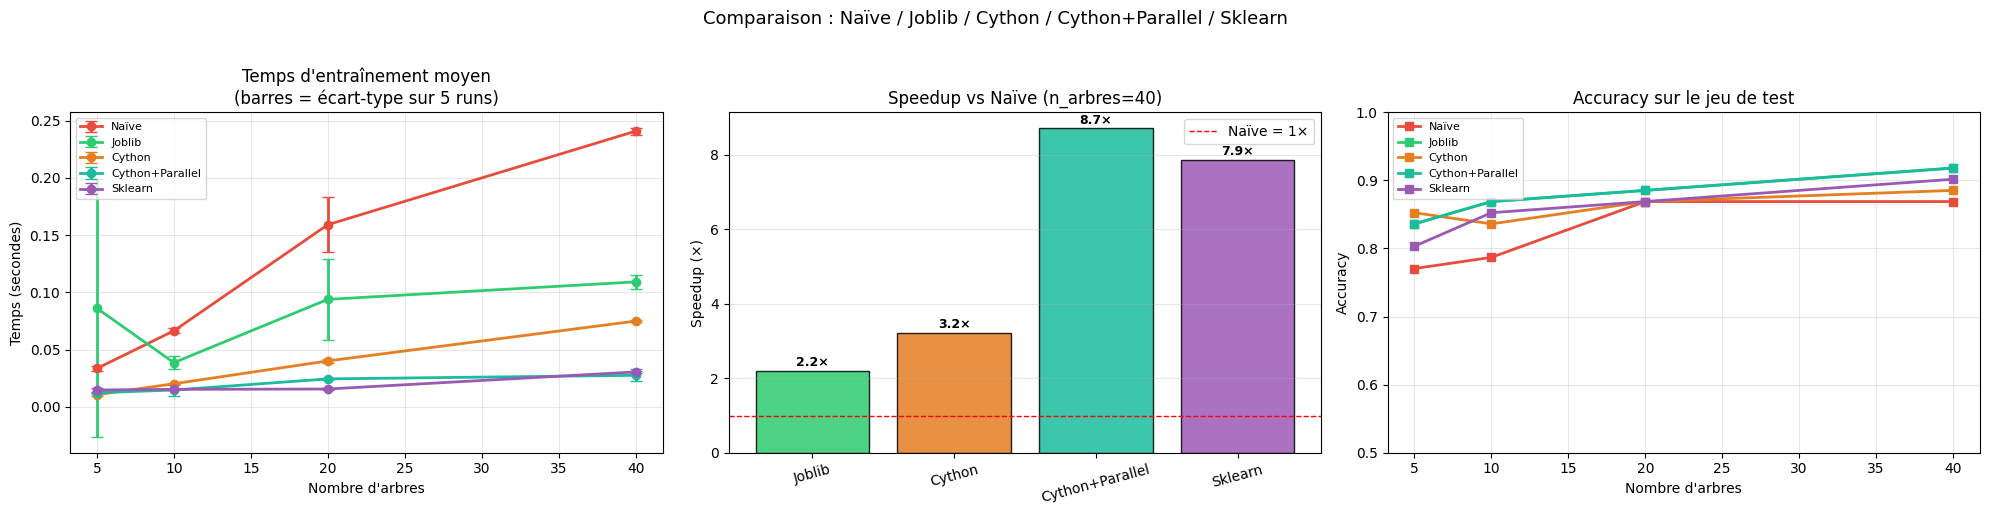

In [8]:
couleurs = {
    "Naïve":           "#e74c3c",
    "Joblib":          "#2ecc71",
    "Cython":          "#e67e22",
    "Cython+Parallel": "#1abc9c",
    "Sklearn":         "#9b59b6",
}

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# --- Graphique 1 : Temps moyen avec écart-type ---
ax = axes[0]
for modele in MODELES_ORDRE:
    sous_df = df_resultats[df_resultats["modele"] == modele]
    ax.errorbar(
        sous_df["n_arbres"], sous_df["temps_moyen"],
        yerr=sous_df["temps_std"],
        marker="o", label=modele, color=couleurs[modele], capsize=4, linewidth=2
    )
ax.set_xlabel("Nombre d'arbres")
ax.set_ylabel("Temps (secondes)")
ax.set_title("Temps d'entraînement moyen\n(barres = écart-type sur 5 runs)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- Graphique 2 : Speedup vs Naïve (barres) ---
ax = axes[1]
n_max = n_arbres_liste[-1]
ligne = df_resultats[df_resultats["n_arbres"] == n_max].set_index("modele")
temps_naive = ligne.loc["Naïve", "temps_moyen"]
modeles_bar = [m for m in MODELES_ORDRE if m != "Naïve"]
speedups_bar = [temps_naive / ligne.loc[m, "temps_moyen"] for m in modeles_bar]
barres = ax.bar(modeles_bar, speedups_bar,
                color=[couleurs[m] for m in modeles_bar], edgecolor="black", alpha=0.85)
ax.axhline(1, color="red", linestyle="--", linewidth=1, label="Naïve = 1×")
for barre, val in zip(barres, speedups_bar):
    ax.text(barre.get_x() + barre.get_width()/2, barre.get_height() + 0.05,
            f"{val:.1f}×", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_ylabel("Speedup (×)")
ax.set_title(f"Speedup vs Naïve (n_arbres={n_max})")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
ax.tick_params(axis="x", rotation=15)

# --- Graphique 3 : Accuracy ---
ax = axes[2]
for modele in MODELES_ORDRE:
    sous_df = df_resultats[df_resultats["modele"] == modele]
    ax.plot(sous_df["n_arbres"], sous_df["accuracy"],
            marker="s", label=modele, color=couleurs[modele], linewidth=2)
ax.set_xlabel("Nombre d'arbres")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy sur le jeu de test")
ax.set_ylim(0.5, 1.0)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle("Comparaison : Naïve / Joblib / Cython / Cython+Parallel / Sklearn", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("benchmark_random_forest.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Boxplot — variabilité des temps sur plusieurs runs

Boxplot : 8 runs, n_arbres=20
  Naïve              0.1384s ± 0.0076s
  Joblib             0.0662s ± 0.0052s
  Cython             0.0404s ± 0.0019s
  Cython+Parallel    0.0249s ± 0.0008s


/var/folders/x5/83lfgsk55sq339swtbb00dk40000gn/T/ipykernel_50291/278939189.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([tous_les_temps[n] for n in noms_box], labels=noms_box, patch_artist=True)


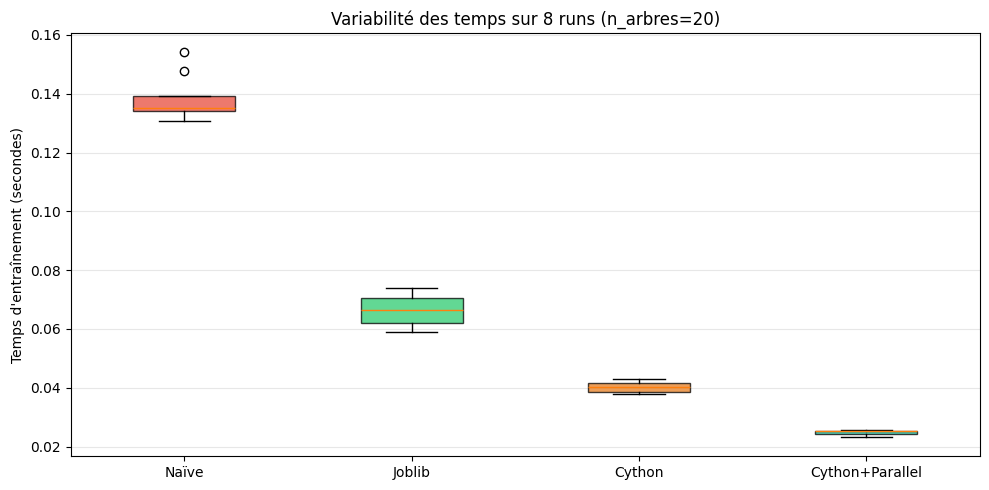

In [9]:
N_ARBRES_DETAIL = 20
N_RUNS_BOX = 8

configs_box = [
    ("Naïve",           RandomForestNaive,
     X_train_list, y_train_list, X_test_list, y_test_list,
     {"n_arbres": N_ARBRES_DETAIL, "profondeur_max": PROFONDEUR_MAX, "graine": GRAINE_GLOBALE}),

    ("Joblib",          RandomForestJoblib,
     X_train_np, y_train_np, X_test_np, y_test_np,
     {"n_arbres": N_ARBRES_DETAIL, "profondeur_max": PROFONDEUR_MAX, "n_jobs": -1, "graine": GRAINE_GLOBALE}),

    ("Cython",          RandomForestCython,
     X_train_np, y_train_np, X_test_np, y_test_np,
     {"n_arbres": N_ARBRES_DETAIL, "profondeur_max": PROFONDEUR_MAX, "graine": GRAINE_GLOBALE}),

    ("Cython+Parallel", RandomForestCythonParallel,
     X_train_np, y_train_np, X_test_np, y_test_np,
     {"n_arbres": N_ARBRES_DETAIL, "profondeur_max": PROFONDEUR_MAX, "n_jobs": -1, "graine": GRAINE_GLOBALE}),
]

tous_les_temps = {}
print(f"Boxplot : {N_RUNS_BOX} runs, n_arbres={N_ARBRES_DETAIL}")

for nom, cls, Xtr, ytr, Xte, yte, kw in configs_box:
    res = benchmark_modele(cls, Xtr, ytr, Xte, yte, n_runs=N_RUNS_BOX, **kw)
    tous_les_temps[nom] = res["tous_les_temps"]
    print(f"  {nom:<18} {res['temps_moyen']:.4f}s ± {res['temps_std']:.4f}s")

noms_box = list(tous_les_temps.keys())
fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot([tous_les_temps[n] for n in noms_box], labels=noms_box, patch_artist=True)
for patch, nom in zip(bp["boxes"], noms_box):
    patch.set_facecolor(couleurs[nom])
    patch.set_alpha(0.75)
ax.set_ylabel("Temps d'entraînement (secondes)")
ax.set_title(f"Variabilité des temps sur {N_RUNS_BOX} runs (n_arbres={N_ARBRES_DETAIL})")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("boxplot_random_forest.png", dpi=150, bbox_inches="tight")
plt.show()